# _4.3.4. (high-gravity anomaly detection) classification using TabNet_

Main topics of the current notebook is to focus on applying TabNet to the problem of high-gravity anomaly detection, i.e., categorizing anomalies into distinct classes : highly affected by reorder, highly affected by duplicate, highly affected by corrupt anomalies or simply normal case.

#### _a. Load Data_

Recall, the dataset was already cleaned and normalized _(using StandardScaler)_. Columns with zero or near-zero variance deleted.

In [1]:
!jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: ok


In [2]:
import pandas as pd
import numpy as np
import os
import time
import torch

from matplotlib import pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import train_test_split

from pytorch_tabnet.tab_model import TabNetClassifier

%matplotlib inline

In [3]:
scaled_new_dataset = "data/scaled_new_godash_dataset.csv"
scaled_new_df = pd.read_csv(scaled_new_dataset, index_col=0)

scaled_new_df.head(2)

,Seg_id,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,Act_Rate,Byte_Size,Buff_Level,Width,...,Yu,algo,nb_nodes,mos,MOS,mos_label,anomaly,level,tag2,tag
0,-1.697807,-0.445033,-0.204334,-0.164204,-1.294465,-1.160341,-1.160370,-1.160361,-0.833377,-1.247338,...,0.360347,-1.462647,0.524565,-1.043858,-0.045817,bad,0,-1.083746,False,0
1,-1.640070,-0.441006,-0.198458,-0.164204,-1.294465,-0.396335,-1.008632,-1.008502,-0.575036,-1.247338,...,0.360347,-1.462647,0.524565,-1.114816,-0.045817,bad,0,-1.083746,False,0


#### _b. add a new column "tag50"_

In [4]:
# {'normal': 0, 'reorder': 1, 'duplicate': 2, 'corrupt': 3}
#                           'normal': 0,
#                       'duplicate5': 1, 'duplicate10': 2,  'duplicate20': 3, 
#                      'duplicate30': 4, 'duplicate40': 5,  'duplicate50': 6,   
#                        'reorder5':  7,  'reorder10':  8,   'reorder20':  9, 
#                       'reorder30': 10,  'reorder40': 11,   'reorder50': 12,                       
#                        'corrupt5': 13,  'corrupt10': 14,   'corrupt20': 15, 
#                       'corrupt30': 16,  'corrupt40': 17,   'corrupt50': 18, 

scaled_new_df.loc[scaled_new_df["tag"]==6, 'tag50'] = 'hight_duplicate_anomaly'
scaled_new_df.loc[scaled_new_df["tag"]==12, 'tag50'] = 'hight_reorder_anomaly'
scaled_new_df.loc[scaled_new_df["tag"]==18, 'tag50'] = 'hight_corrupt_anomaly'
scaled_new_df.loc[scaled_new_df["tag"]==0, 'tag50'] = 'normal'
target = "tag50"
scaled_new_df[target].value_counts()

normal                     21660
hight_reorder_anomaly       3600
hight_duplicate_anomaly     3600
hight_corrupt_anomaly       2811
Name: tag50, dtype: int64

In [5]:
scaled_hight_df = scaled_new_df[~scaled_new_df.tag50.isna()].copy()
scaled_hight_df.shape

(31671, 28)

#### _c. label encode new added column_

In [6]:
from sklearn.preprocessing import LabelEncoder
custom_mapping_tag50 = {'normal': 0,
                        'hight_reorder_anomaly': 1, 
                        'hight_duplicate_anomaly': 2, 
                        'hight_corrupt_anomaly': 3}
    
le_tag50 = LabelEncoder()
le_tag50.classes_ = list(custom_mapping_tag50.keys())
scaled_hight_df["tag50"] = le_tag50.transform(scaled_hight_df["tag50"])
print (le_tag50.classes_)
scaled_hight_df["tag50"].value_counts()

['normal', 'hight_reorder_anomaly', 'hight_duplicate_anomaly', 'hight_corrupt_anomaly']


0    21660
1     3600
2     3600
3     2811
Name: tag50, dtype: int64

In [7]:
n_total = len(scaled_hight_df)
print ("n_total = ", n_total)
print ("nb features =", len(scaled_hight_df.columns))
print ("nan values =", scaled_hight_df.isna().sum().sum())

n_total =  31671
nb features = 28
nan values = 0


In [8]:
all_features = ['Seg_id', 'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', 'Del_Rate',
                'Act_Rate', 'Byte_Size', 'Buff_Level',  'Width',
                'Height', 'Play_Pos', 'RTT',  'P.1203', 'Clae',
                'Duanmu', 'Yin', 'Yu', 'algo', 'nb_nodes', 'mos', 'MOS', 'mos_label', 
                'anomaly', 'level', 'tag2', 'tag']
new_df = scaled_hight_df [all_features]
selected_features = all_features[:-4]
target = "anomaly"

In [9]:
dataset_name = 'new_godash_dataset'
train = new_df.copy()
n_total = len(train)
print ("n_total = ", n_total)
print ("nb features =", len(train.columns))
print ("nan values =", train.isna().sum().sum())

n_total =  31671
nb features = 27
nan values = 0


#### _d. Label Encode target y_

The basic Idea here is to see the problem as a multi-class classification problem. 

The population is already devided into different anomalies tag using "anomaly" column.

In [10]:
train[target].value_counts(normalize=True)

0    0.683906
1    0.113669
2    0.113669
3    0.088756
Name: anomaly, dtype: float64

In [11]:
# {'normal': 0, 'reorder': 1, 'duplicate': 2, 'corrupt': 3}
train["anomaly"].value_counts()

0    21660
1     3600
2     3600
3     2811
Name: anomaly, dtype: int64

#### _e. Split_

In [12]:
train_val_indices, test_indices = train_test_split(range(n_total), test_size=0.2, random_state=0)
train_indices, valid_indices = train_test_split(train_val_indices, test_size=0.2 / 0.6, random_state=0)

# This is a generic pipeline but actually no categorical features are available for this dataset
unused_feat = ["mos_label", 'anomaly', 'level', 'tag']
features = [ col for col in selected_features if col not in unused_feat+[target]] 

X_train = train[features].values[train_indices]
y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("X_train (shape) = ", X_train.shape, "--> ", round((X_train.shape[0]/train.shape[0])*100,2), "%")
print ("X_valid (shape) = ", X_valid.shape, "--> ", round((X_valid.shape[0]/train.shape[0])*100,2), "%")
print ("X_test (shape)  = ", X_test.shape, "--> ", round((X_test.shape[0]/train.shape[0])*100,2), "%\n\n")

print ("y_train (shape) = ", y_train.shape)
print ("y_valid (shape) = ", y_valid.shape)
print ("y_test (shape)  = ", y_test.shape)

X_train (shape) =  (16890, 22) -->  53.33 %
X_valid (shape) =  (8446, 22) -->  26.67 %
X_test (shape)  =  (6335, 22) -->  20.0 %


y_train (shape) =  (16890,)
y_valid (shape) =  (8446,)
y_test (shape)  =  (6335,)


##### _f. Categorical features_

We need to identify categorical features before training in Tabnet

In [13]:
nunique = train.nunique()
types = train.dtypes

categorical_columns = []
categorical_dims =  {}
for col in train.columns:
    if types[col] == 'object' or nunique[col] < 200:
        print(col, train[col].nunique())
        l_enc = LabelEncoder()
        train[col] = train[col].fillna("VV_likely")
        train[col] = l_enc.fit_transform(train[col].values)
        categorical_columns.append(col)
        categorical_dims[col] = len(l_enc.classes_)

Seg_id 60
Rep_Level 8
Width 6
Height 6
Play_Pos 60
algo 6
nb_nodes 10
MOS 5
mos_label 5
anomaly 4
level 2
tag2 2
tag 4


In [14]:
cat_idxs = [ i for i, f in enumerate(features) if f in categorical_columns]
cat_dims = [ categorical_dims[f] for i, f in enumerate(features) if f in categorical_columns]

pd.DataFrame({"cathegorical_features" : np.array(features)[cat_idxs],\
              "feat_index" : cat_idxs,\
              "cat_dimention" : cat_dims })

,cathegorical_features,feat_index,cat_dimention
0,Seg_id,0,60
1,Rep_Level,4,8
2,Width,9,6
3,Height,10,6
4,Play_Pos,11,60
5,algo,18,6
6,nb_nodes,19,10
7,MOS,21,5


In [15]:
X_train = train[features].values[train_indices]
y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("X_train (shape) = ", X_train.shape, "--> ", round((X_train.shape[0]/train.shape[0])*100,2), "%")
print ("X_valid (shape) = ", X_valid.shape, "--> ", round((X_valid.shape[0]/train.shape[0])*100,2), "%")
print ("X_test (shape)  = ", X_test.shape, "--> ", round((X_test.shape[0]/train.shape[0])*100,2), "%\n\n")

print ("y_train (shape) = ", y_train.shape)
print ("y_valid (shape) = ", y_valid.shape)
print ("y_test (shape)  = ", y_test.shape)

X_train (shape) =  (16890, 22) -->  53.33 %
X_valid (shape) =  (8446, 22) -->  26.67 %
X_test (shape)  =  (6335, 22) -->  20.0 %


y_train (shape) =  (16890,)
y_valid (shape) =  (8446,)
y_test (shape)  =  (6335,)


##### _g. Grouped features_

You can now specify groups of feature which will share a common attention.

This may be very usefull for features comming from a same preprocessing technique like PCA for example.

In [16]:
grouped_features = [[0, 1, 2], [8, 9, 10]]
pd.DataFrame({"group_01" : np.array(features)[grouped_features[0]],\
              "group_02" : np.array(features)[grouped_features[1]]})

,group_01,group_02
0,Seg_id,Buff_Level
1,Arr_time,Width
2,Del_Time,Height


#### _h. Check CUDA support_

In [17]:
print ("Is CUDA available :", torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print ("Device :", DEVICE)

Is CUDA available : True
Device : cuda


In [18]:
os.environ['CUDA_VISIBLE_DEVICES'] = f"1"

print ("Is Torsh available --> ", torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE 

Is Torsh available -->  True


'cuda'

In [19]:
torch.__version__

'1.9.0+cu111'

In [20]:
from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

### _i. Classification using TabNet_

While traditional vanilla _**neural networks**_ can be powerful, they may encounter certain pitfalls in the context of anomaly detection _(motivating the exploration of alternative architectures)_ 

This includes :

-  Lack of support of Sequential/Tabular Data 

-  Lack of Interpretability


Developed by Google Cloud AI researchers, _**TabNet**_ introduces innovations that make it well-suited for tasks involving datasets with rows and columns, and where interpretability is a critical requirement.


<br>

<div style="float: center;"><img  src="docs\pics\tabnet_google.png"  alt="binary_nn"  width="400"/>
</div>

</br>

We used [**_dreamquark-ai/tabnet_**](https://github.com/dreamquark-ai/tabnet), a **_PyTorsh_** implementation of tabnet based on the [[original paper]](https://arxiv.org/pdf/1908.07442.pdf). 

As an hyper-parameter-tuning, we have to choose between _**AUC**_ vs _**logloss**_ as an _**evaluation metric**_. 

### _1. Using AUC_

In [21]:
clf = TabNetClassifier(
    n_d=64, n_a=64, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=1,
    lambda_sparse=1e-4, momentum=0.3, clip_value=2.,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params = {"gamma": 0.95, "step_size": 20},
    scheduler_fn=torch.optim.lr_scheduler.StepLR, epsilon=1e-15,
    device_name = DEVICE
)

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [22]:
X_valid.shape

(8446, 22)

In [23]:
max_epochs = 100 if not os.getenv("CI", False) else 2
from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    max_epochs=max_epochs, patience=100,
    batch_size=3303, virtual_batch_size=256,
    # batch_size=1024, virtual_batch_size=256,    
    augmentations=aug
) 

epoch 0  | loss: 1.36325 | train_accuracy: 0.72872 | valid_accuracy: 0.7355  |  0:00:02s
epoch 1  | loss: 0.81736 | train_accuracy: 0.76234 | valid_accuracy: 0.76735 |  0:00:04s
epoch 2  | loss: 0.68858 | train_accuracy: 0.7389  | valid_accuracy: 0.74651 |  0:00:05s
epoch 3  | loss: 0.63758 | train_accuracy: 0.77194 | valid_accuracy: 0.77859 |  0:00:07s
epoch 4  | loss: 0.60331 | train_accuracy: 0.78863 | valid_accuracy: 0.79813 |  0:00:09s
epoch 5  | loss: 0.57849 | train_accuracy: 0.77395 | valid_accuracy: 0.78084 |  0:00:10s
epoch 6  | loss: 0.56133 | train_accuracy: 0.79331 | valid_accuracy: 0.80038 |  0:00:12s
epoch 7  | loss: 0.52364 | train_accuracy: 0.80977 | valid_accuracy: 0.82086 |  0:00:14s
epoch 8  | loss: 0.53161 | train_accuracy: 0.81427 | valid_accuracy: 0.82335 |  0:00:15s
epoch 9  | loss: 0.50921 | train_accuracy: 0.8087  | valid_accuracy: 0.82311 |  0:00:17s
epoch 10 | loss: 0.49379 | train_accuracy: 0.81664 | valid_accuracy: 0.82583 |  0:00:18s
epoch 11 | loss: 0.47

epoch 93 | loss: 0.21829 | train_accuracy: 0.95382 | valid_accuracy: 0.95513 |  0:02:36s
epoch 94 | loss: 0.21457 | train_accuracy: 0.94985 | valid_accuracy: 0.953   |  0:02:37s
epoch 95 | loss: 0.21194 | train_accuracy: 0.94944 | valid_accuracy: 0.95323 |  0:02:39s
epoch 96 | loss: 0.21195 | train_accuracy: 0.9492  | valid_accuracy: 0.95193 |  0:02:41s
epoch 97 | loss: 0.21402 | train_accuracy: 0.95175 | valid_accuracy: 0.95323 |  0:02:42s
epoch 98 | loss: 0.19949 | train_accuracy: 0.9553  | valid_accuracy: 0.95702 |  0:02:44s
epoch 99 | loss: 0.20226 | train_accuracy: 0.95613 | valid_accuracy: 0.95939 |  0:02:46s
Stop training because you reached max_epochs = 100 with best_epoch = 99 and best_valid_accuracy = 0.95939


C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


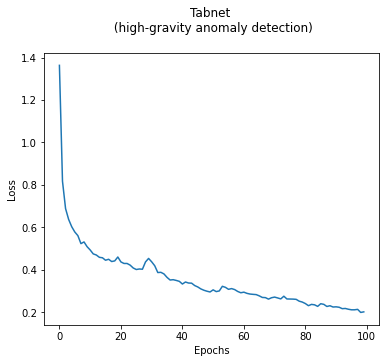

In [24]:
# plot losses
plt.figure(figsize=(6,5))
plt.plot(clf.history['loss'])
plt.title('Tabnet \n (high-gravity anomaly detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

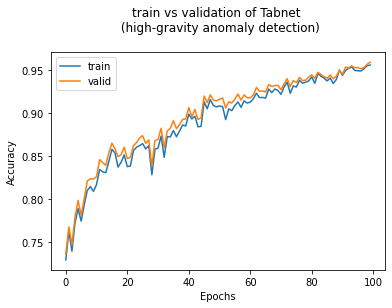

In [63]:
plt.plot(clf.history['train_accuracy'], label="train")
plt.plot(clf.history['valid_accuracy'], label="valid")
plt.title('train vs validation of Tabnet \n (high-gravity anomaly detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

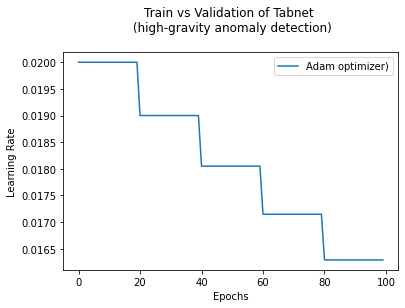

In [26]:
# plot learning rates
plt.plot(clf.history['lr'], label="Adam optimizer)")
plt.title('Train vs Validation of Tabnet \n (high-gravity anomaly detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.legend()

##### _Evaluate_

In [27]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_valid = clf.predict(X_valid)
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

# Calculate accuracy
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Validation Accuracy:", valid_accuracy)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Validation Accuracy: 0.9593890599100166
Train Accuracy: 0.9561278863232682
Test Accuracy: 0.9556432517758484


Evaluate using test set :

In [28]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_test = clf.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9556432517758484


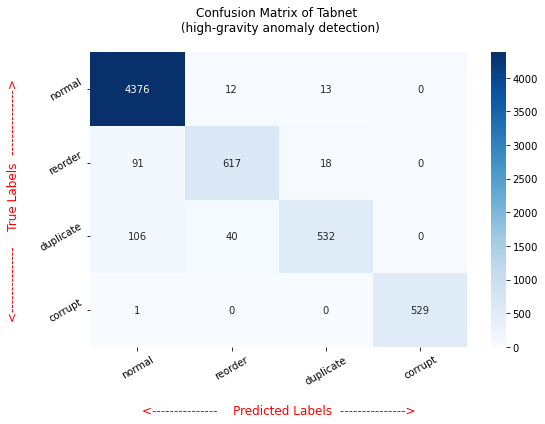

In [29]:
from sklearn.metrics import confusion_matrix, classification_report


# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

import seaborn as sns
import matplotlib.pyplot as plt

labeled_classes = ['normal','reorder', 'duplicate','corrupt']
classes = np.unique(y_train) 
classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labeled_classes, rotation=30)
plt.yticks(classes, labeled_classes, rotation=30)
plt.xlabel("<---------------    Predicted Labels  --------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<---------------    True Labels  --------------->",  fontsize=12, color="red", labelpad=18)
plt.title('Confusion Matrix of Tabnet \n (high-gravity anomaly detection)\n')
plt.tight_layout()
plt.show()

In [30]:
# Display a classification report
print("                  TabNet Classification Report")
print("                (high-gravity anomaly detection)\n")
print(classification_report(y_test, y_pred_test))

                  TabNet Classification Report
                (high-gravity anomaly detection)

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      4401
           1       0.92      0.85      0.88       726
           2       0.94      0.78      0.86       678
           3       1.00      1.00      1.00       530

    accuracy                           0.96      6335
   macro avg       0.96      0.91      0.93      6335
weighted avg       0.96      0.96      0.95      6335



##### _Global explainability : feat importance summing to 1_

In [31]:
scorez = clf.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(20)

,feature,score,f_indice,rank
0,Del_Rate,0.380236,5,1
1,Buff_Level,0.117323,8,2
2,P.1203,0.093012,13,3
3,nb_nodes,0.082508,19,4
4,Byte_Size,0.051933,7,5
5,Height,0.050504,10,6
6,Width,0.040570,9,7
7,Clae,0.030525,14,8
8,Del_Time,0.027953,2,9
9,Yu,0.027147,17,10


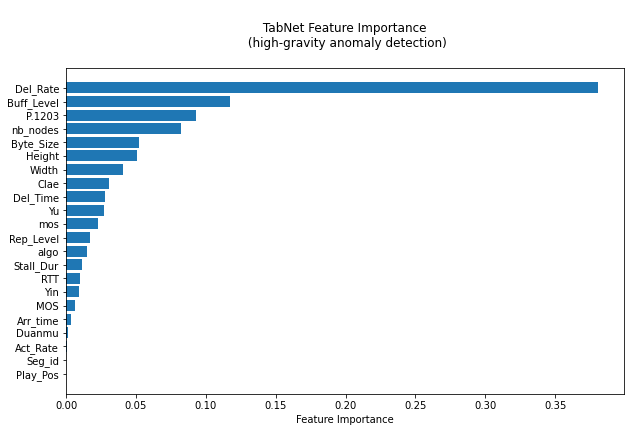

In [32]:
feature_importance = clf.feature_importances_

# Map feature names to importance scores
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("\n TabNet Feature Importance \n (high-gravity anomaly detection)\n")
plt.show()

#### _Local explainability and masks_

In [33]:
explain_matrix, masks = clf.explain(X_test)
print (masks.keys())
masks[0][:50].shape

dict_keys([0, 1, 2, 3, 4])


(50, 22)

In [35]:
tabnet_params = {"cat_idxs":cat_idxs,
                 "cat_dims":cat_dims,
                 "cat_emb_dim":2,
                 "optimizer_fn":torch.optim.Adam,
                 "optimizer_params":dict(lr=2e-2),
                 "scheduler_params":{"step_size":50, # how to use learning rate scheduler
                                 "gamma":0.9},
                 "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                 "mask_type":'entmax', # "sparsemax"
                 ##"grouped_features" : grouped_features,
                  "device_name" : "auto"                 
                }

acc_clf = TabNetClassifier(**tabnet_params)

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


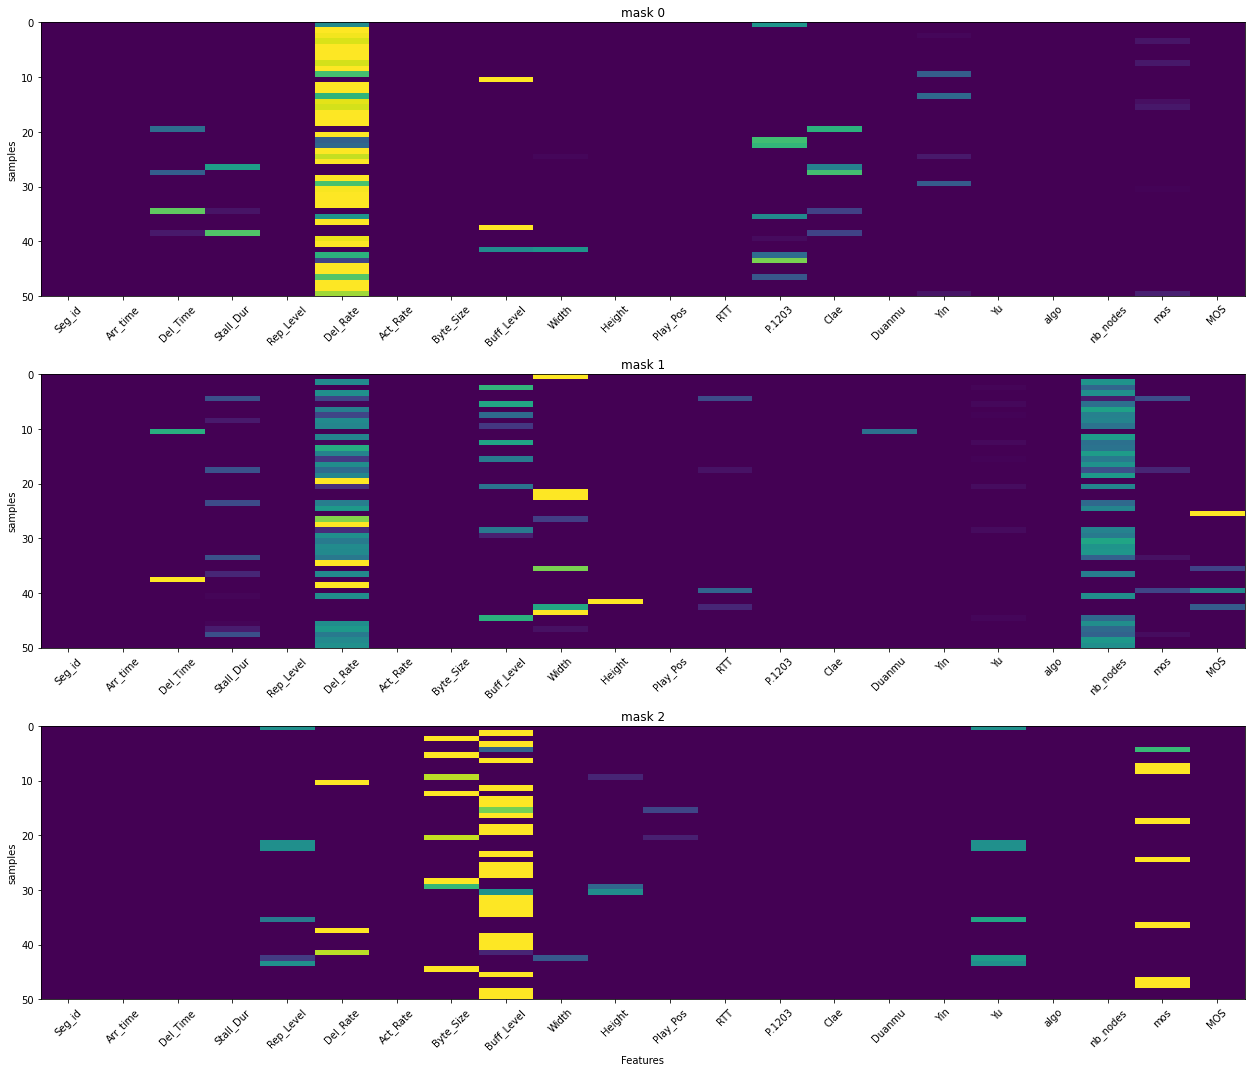

In [34]:
fig, axs = plt.subplots(3, 1, figsize=(20,15))
features_index = [x*20+10 for x in range(len(features))]
for i in range(3):
    axs[i].set_xticks(features_index)
    axs[i].imshow(masks[i][:50], extent=[0, 440, 50, 0], aspect=2)
    axs[i].set_xticklabels(features, rotation=45)
    axs[i].set_title(f"mask {i}")
    axs[i].set_ylabel("samples")    
axs[i].set_xlabel("Features")    
fig.tight_layout()

### _1. Using Accuracy as an Evaluation metric_ 

In [36]:
max_epochs = 100 if not os.getenv("CI", False) else 2

from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

In [37]:
# This illustrates the warm_start=False behaviour
save_history = []
start_time = time.time()

# Fitting the model without starting from a warm start nor computing the feature importance
for _ in range(2):
    acc_clf.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        eval_name=['train', 'valid'],
        eval_metric=['accuracy'],
        max_epochs=max_epochs , # max_epochs=11, patience=20,
        batch_size=1024, virtual_batch_size=128,
        num_workers=0,
        weights=1,
        drop_last=False,
        augmentations=aug, #aug, None
        compute_importance=True
    )
    save_history.append(acc_clf.history["valid_accuracy"])

assert(np.all(np.array(save_history[0]==np.array(save_history[1]))))

print(f"Training completed in {(time.time()-start_time)//60:.2f} mnt.")

epoch 0  | loss: 1.14495 | train_accuracy: 0.7325  | valid_accuracy: 0.73964 |  0:00:02s
epoch 1  | loss: 0.71802 | train_accuracy: 0.737   | valid_accuracy: 0.73159 |  0:00:04s
epoch 2  | loss: 0.59016 | train_accuracy: 0.61889 | valid_accuracy: 0.60857 |  0:00:06s
epoch 3  | loss: 0.5346  | train_accuracy: 0.74227 | valid_accuracy: 0.73301 |  0:00:09s
epoch 4  | loss: 0.45683 | train_accuracy: 0.78733 | valid_accuracy: 0.7825  |  0:00:11s
epoch 5  | loss: 0.36963 | train_accuracy: 0.82102 | valid_accuracy: 0.82205 |  0:00:13s
epoch 6  | loss: 0.32692 | train_accuracy: 0.87886 | valid_accuracy: 0.87781 |  0:00:15s
epoch 7  | loss: 0.29461 | train_accuracy: 0.88034 | valid_accuracy: 0.87982 |  0:00:17s
epoch 8  | loss: 0.26778 | train_accuracy: 0.89266 | valid_accuracy: 0.88942 |  0:00:20s
epoch 9  | loss: 0.27352 | train_accuracy: 0.92552 | valid_accuracy: 0.92328 |  0:00:22s
epoch 10 | loss: 0.25156 | train_accuracy: 0.92416 | valid_accuracy: 0.9234  |  0:00:24s
epoch 11 | loss: 0.24

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.14495 | train_accuracy: 0.7325  | valid_accuracy: 0.73964 |  0:00:02s
epoch 1  | loss: 0.71802 | train_accuracy: 0.737   | valid_accuracy: 0.73159 |  0:00:04s
epoch 2  | loss: 0.59016 | train_accuracy: 0.61889 | valid_accuracy: 0.60857 |  0:00:06s
epoch 3  | loss: 0.5346  | train_accuracy: 0.74227 | valid_accuracy: 0.73301 |  0:00:08s
epoch 4  | loss: 0.45683 | train_accuracy: 0.78733 | valid_accuracy: 0.7825  |  0:00:11s
epoch 5  | loss: 0.36963 | train_accuracy: 0.82102 | valid_accuracy: 0.82205 |  0:00:13s
epoch 6  | loss: 0.32692 | train_accuracy: 0.87886 | valid_accuracy: 0.87781 |  0:00:15s
epoch 7  | loss: 0.29461 | train_accuracy: 0.88034 | valid_accuracy: 0.87982 |  0:00:17s
epoch 8  | loss: 0.26778 | train_accuracy: 0.89266 | valid_accuracy: 0.88942 |  0:00:19s
epoch 9  | loss: 0.27352 | train_accuracy: 0.92552 | valid_accuracy: 0.92328 |  0:00:21s
epoch 10 | loss: 0.25156 | train_accuracy: 0.92416 | valid_accuracy: 0.9234  |  0:00:24s
epoch 11 | loss: 0.24

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training completed in 2.00 mnt.


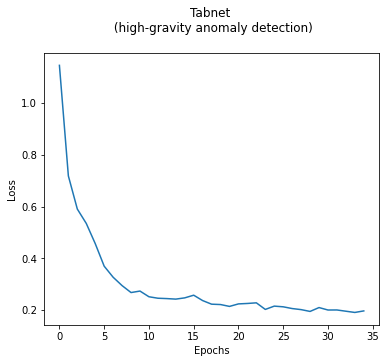

In [38]:
# plot losses
plt.figure(figsize=(6,5))
plt.plot(acc_clf.history['loss'])
plt.title('Tabnet \n (high-gravity anomaly detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
#plt.legend()
plt.show()

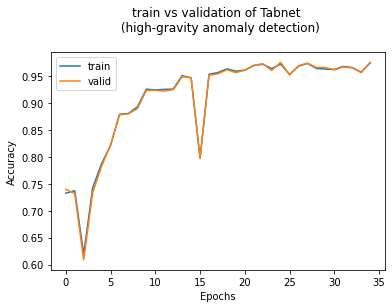

In [39]:
# plot acc
plt.plot(acc_clf.history['train_accuracy'], label="train")
plt.plot(acc_clf.history['valid_accuracy'], label="valid")

plt.title('train vs validation of Tabnet \n (high-gravity anomaly detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

##### _Evaluate_

In [40]:
from sklearn.metrics import silhouette_score, accuracy_score, mean_squared_error, r2_score

# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_valid = acc_clf.predict(X_valid)
y_pred_train = acc_clf.predict(X_train)
y_pred_test = acc_clf.predict(X_test)

# Calculate accuracy
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Validation Accuracy:", valid_accuracy)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Validation Accuracy: 0.9754913568553161
Train Accuracy: 0.9720544701006513
Test Accuracy: 0.9687450670876085


Evaluate using test set :

In [41]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_test = acc_clf.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9687450670876085


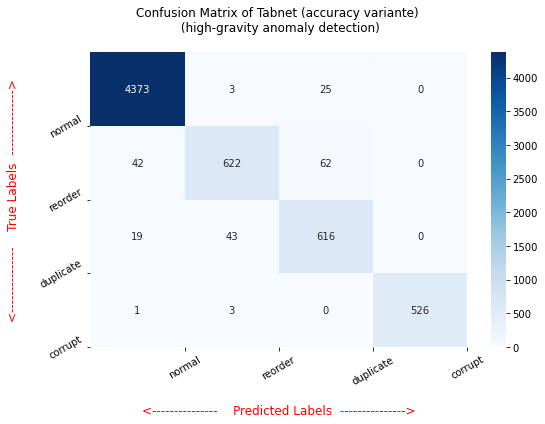

In [42]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

import seaborn as sns
import matplotlib.pyplot as plt


labeled_classes = ['normal','(high) reorder', '(high) duplicate','(high) corrupt']
classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labeled_classes, rotation=30)
plt.yticks(classes, labeled_classes, rotation=30)
plt.xlabel("<---------------    Predicted Labels  --------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<---------------    True Labels  --------------->",  fontsize=12, color="red", labelpad=18)
plt.title('Confusion Matrix of Tabnet (accuracy variante) \n (high-gravity anomaly detection)\n')
plt.tight_layout()
plt.show()

In [43]:
# Display a classification report
print("                  TabNet Classification Report")
print("                (high-gravity anomaly detection)\n")
print(classification_report(y_test, y_pred_test))

                  TabNet Classification Report
                (high-gravity anomaly detection)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4401
           1       0.93      0.86      0.89       726
           2       0.88      0.91      0.89       678
           3       1.00      0.99      1.00       530

    accuracy                           0.97      6335
   macro avg       0.95      0.94      0.94      6335
weighted avg       0.97      0.97      0.97      6335



##### _Global explainability : feat importance summing to 1_

In [44]:
scorez = acc_clf.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(20)

,feature,score,f_indice,rank
0,Del_Rate,0.245187,5,1
1,nb_nodes,0.162700,19,2
2,Width,0.109489,9,3
3,P.1203,0.100466,13,4
4,Clae,0.088373,14,5
5,Byte_Size,0.047861,7,6
6,Buff_Level,0.037981,8,7
7,Yu,0.036957,17,8
8,Arr_time,0.035001,1,9
9,Height,0.034868,10,10


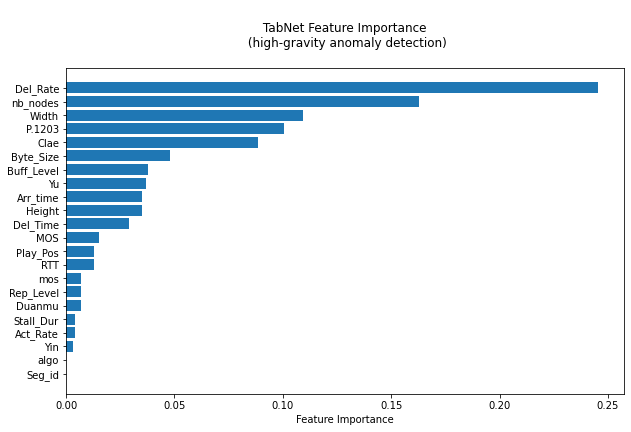

In [45]:
feature_importance = acc_clf.feature_importances_

# Map feature names to importance scores
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("\n TabNet Feature Importance \n (high-gravity anomaly detection)\n")
plt.show()

#### _Local explainability and masks_

In [46]:
explain_matrix, masks = acc_clf.explain(X_test)
print (masks.keys())
masks[0][:50].shape

dict_keys([0, 1, 2])


(50, 22)

In [47]:
len(features)

22

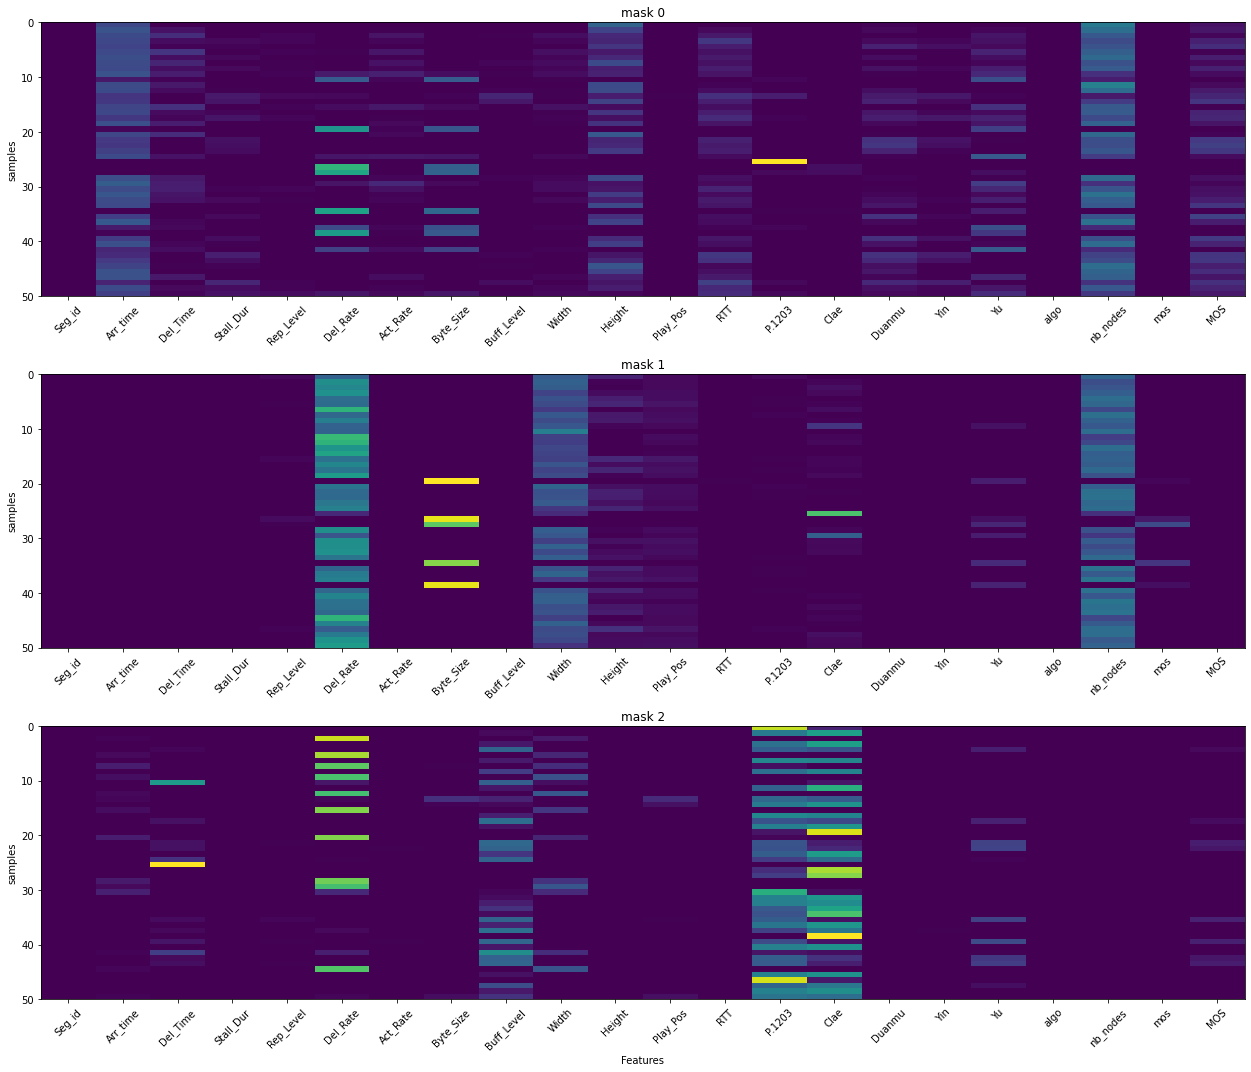

In [48]:
fig, axs = plt.subplots(3, 1, figsize=(20,15))
features_index = [x*20+10 for x in range(len(features))]
for i in range(3):
    axs[i].set_xticks(features_index)
    axs[i].imshow(masks[i][:50], extent=[0, 440, 50, 0], aspect=2)
    axs[i].set_xticklabels(features, rotation=45)
    axs[i].set_title(f"mask {i}")
    axs[i].set_ylabel("samples")    
axs[i].set_xlabel("Features")    
fig.tight_layout()

### _2. Using logloss_

In [49]:
tabnet_params = {"cat_idxs":cat_idxs,
                 "cat_dims":cat_dims,
                 "cat_emb_dim":2,
                 "optimizer_fn":torch.optim.Adam,
                 "optimizer_params":dict(lr=2e-2),
                 "scheduler_params":{"step_size":50, # how to use learning rate scheduler
                                 "gamma":0.9},
                 "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                 "mask_type":'entmax', # "sparsemax"
                 # "grouped_features" : grouped_features,
                 "device_name" : "auto"                 
                }

loss_clf = TabNetClassifier(**tabnet_params)

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [50]:
# This illustrates the warm_start=False behaviour
save_history = []
start_time = time.time()

# Fitting the model without starting from a warm start nor computing the feature importance
for _ in range(2):
    loss_clf.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        eval_name=['train', 'valid'],
        eval_metric=['logloss'],
        max_epochs=max_epochs , # patience=20,
        batch_size=1024, virtual_batch_size=128,
        num_workers=0,
        weights=1,
        drop_last=False,
        augmentations=aug, #aug, None
        compute_importance=True
    )
    save_history.append(loss_clf.history["valid_logloss"])

assert(np.all(np.array(save_history[0]==np.array(save_history[1]))))

print(f"Training completed in {(time.time()-start_time)//60:.2f} mnt.")

epoch 0  | loss: 1.14495 | train_logloss: 0.81755 | valid_logloss: 0.8111  |  0:00:02s
epoch 1  | loss: 0.71802 | train_logloss: 0.67725 | valid_logloss: 0.6822  |  0:00:04s
epoch 2  | loss: 0.59016 | train_logloss: 0.76043 | valid_logloss: 0.76245 |  0:00:06s
epoch 3  | loss: 0.5346  | train_logloss: 0.57105 | valid_logloss: 0.58183 |  0:00:08s
epoch 4  | loss: 0.45683 | train_logloss: 0.47035 | valid_logloss: 0.47784 |  0:00:10s
epoch 5  | loss: 0.36963 | train_logloss: 0.43243 | valid_logloss: 0.4354  |  0:00:13s
epoch 6  | loss: 0.32692 | train_logloss: 0.327   | valid_logloss: 0.33267 |  0:00:15s
epoch 7  | loss: 0.29461 | train_logloss: 0.29504 | valid_logloss: 0.2949  |  0:00:17s
epoch 8  | loss: 0.26778 | train_logloss: 0.26092 | valid_logloss: 0.26616 |  0:00:19s
epoch 9  | loss: 0.27352 | train_logloss: 0.19415 | valid_logloss: 0.1956  |  0:00:22s
epoch 10 | loss: 0.25156 | train_logloss: 0.19667 | valid_logloss: 0.19933 |  0:00:24s
epoch 11 | loss: 0.24587 | train_logloss: 0

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.14495 | train_logloss: 0.81755 | valid_logloss: 0.8111  |  0:00:02s
epoch 1  | loss: 0.71802 | train_logloss: 0.67725 | valid_logloss: 0.6822  |  0:00:04s
epoch 2  | loss: 0.59016 | train_logloss: 0.76043 | valid_logloss: 0.76245 |  0:00:06s
epoch 3  | loss: 0.5346  | train_logloss: 0.57105 | valid_logloss: 0.58183 |  0:00:08s
epoch 4  | loss: 0.45683 | train_logloss: 0.47035 | valid_logloss: 0.47784 |  0:00:10s
epoch 5  | loss: 0.36963 | train_logloss: 0.43243 | valid_logloss: 0.4354  |  0:00:13s
epoch 6  | loss: 0.32692 | train_logloss: 0.327   | valid_logloss: 0.33267 |  0:00:15s
epoch 7  | loss: 0.29461 | train_logloss: 0.29504 | valid_logloss: 0.2949  |  0:00:17s
epoch 8  | loss: 0.26778 | train_logloss: 0.26092 | valid_logloss: 0.26616 |  0:00:19s
epoch 9  | loss: 0.27352 | train_logloss: 0.19415 | valid_logloss: 0.1956  |  0:00:21s
epoch 10 | loss: 0.25156 | train_logloss: 0.19667 | valid_logloss: 0.19933 |  0:00:24s
epoch 11 | loss: 0.24587 | train_logloss: 0

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training completed in 3.00 mnt.


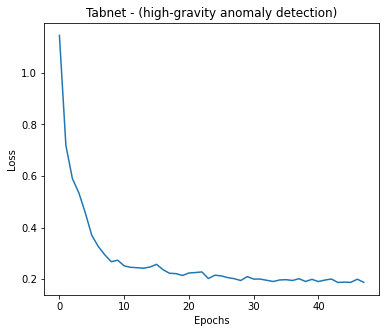

In [51]:
# plot losses
plt.figure(figsize=(6,5))
plt.plot(loss_clf.history['loss'])
plt.title('Tabnet - (high-gravity anomaly detection)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
#plt.legend()
plt.show()

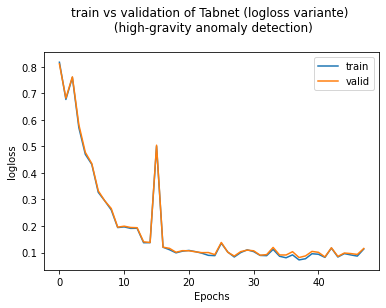

In [52]:
# plot logloss
plt.plot(loss_clf.history['train_logloss'], label="train")
plt.plot(loss_clf.history['valid_logloss'], label="valid")
plt.title('train vs validation of Tabnet (logloss variante) \n (high-gravity anomaly detection)\n')
plt.xlabel('Epochs')
plt.ylabel('logloss')
plt.legend()

In [53]:
# check that best weights are used
# assert np.isclose(valid_auc, np.max(clf.history['valid_logloss']), atol=1e-6)

In [54]:
loss_clf.predict(X_test)

array([2, 0, 1, ..., 0, 0, 0], dtype=int64)

##### _Evaluate_

In [55]:
from sklearn.metrics import silhouette_score, accuracy_score, mean_squared_error, r2_score

# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_valid = loss_clf.predict(X_valid)
y_pred_train = loss_clf.predict(X_train)
y_pred_test = loss_clf.predict(X_test)

# Calculate accuracy
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Validation Accuracy:", valid_accuracy)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Validation Accuracy: 0.9779777409424579
Train Accuracy: 0.9773830669034932
Test Accuracy: 0.9742699289660616


Evaluate using test set :

In [56]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_test = loss_clf.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9742699289660616


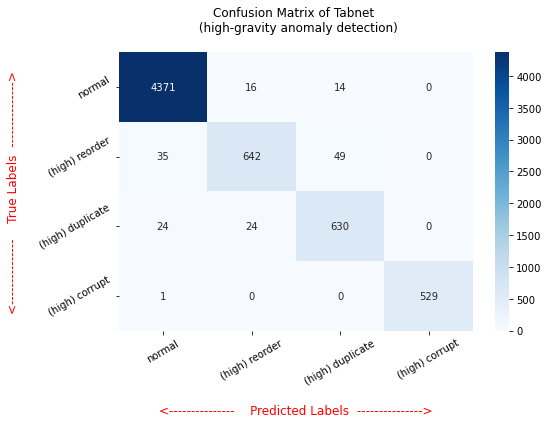

In [57]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

import seaborn as sns
import matplotlib.pyplot as plt


labeled_classes = ['normal','(high) reorder', '(high) duplicate','(high) corrupt']
classes = np.unique(y_train) 
classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labeled_classes, rotation=30)
plt.yticks(classes, labeled_classes, rotation=30)
plt.xlabel("<---------------    Predicted Labels  --------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<---------------    True Labels  --------------->",  fontsize=12, color="red", labelpad=18)
plt.title('Confusion Matrix of Tabnet \n (high-gravity anomaly detection)\n')
plt.tight_layout()
plt.show()

In [58]:
# Display a classification report
print("                  TabNet Classification Report")
print("                (high-gravity anomaly detection)\n")
print(classification_report(y_test, y_pred_test))

                  TabNet Classification Report
                (high-gravity anomaly detection)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4401
           1       0.94      0.88      0.91       726
           2       0.91      0.93      0.92       678
           3       1.00      1.00      1.00       530

    accuracy                           0.97      6335
   macro avg       0.96      0.95      0.95      6335
weighted avg       0.97      0.97      0.97      6335



#### _Global explainability : feat importance summing to 1_

In [59]:
scorez = loss_clf.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(20)

,feature,score,f_indice,rank
0,Del_Rate,0.224197,5,1
1,nb_nodes,0.147400,19,2
2,Width,0.107506,9,3
3,P.1203,0.091612,13,4
4,Clae,0.090163,14,5
5,Byte_Size,0.051009,7,6
6,Arr_time,0.046068,1,7
7,Height,0.035989,10,8
8,Del_Time,0.033466,2,9
9,Play_Pos,0.032503,11,10


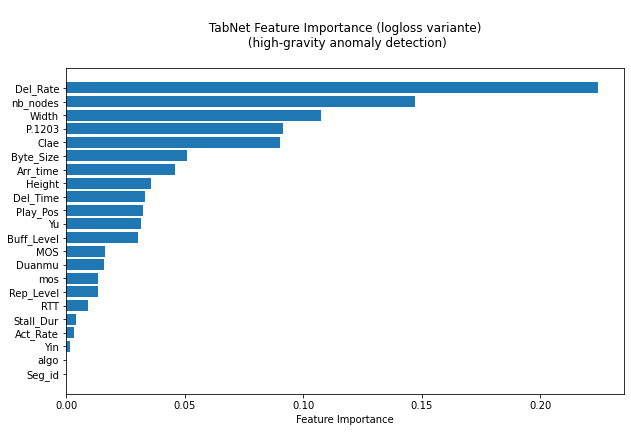

In [60]:
feature_importance = loss_clf.feature_importances_

# Map feature names to importance scores
# feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("\n TabNet Feature Importance (logloss variante) \n (high-gravity anomaly detection)\n")
plt.show()

#### _Local explainability and masks_

In [61]:
explain_matrix, masks = loss_clf.explain(X_test)
print (masks.keys())
masks[0][:50].shape

dict_keys([0, 1, 2])


(50, 22)

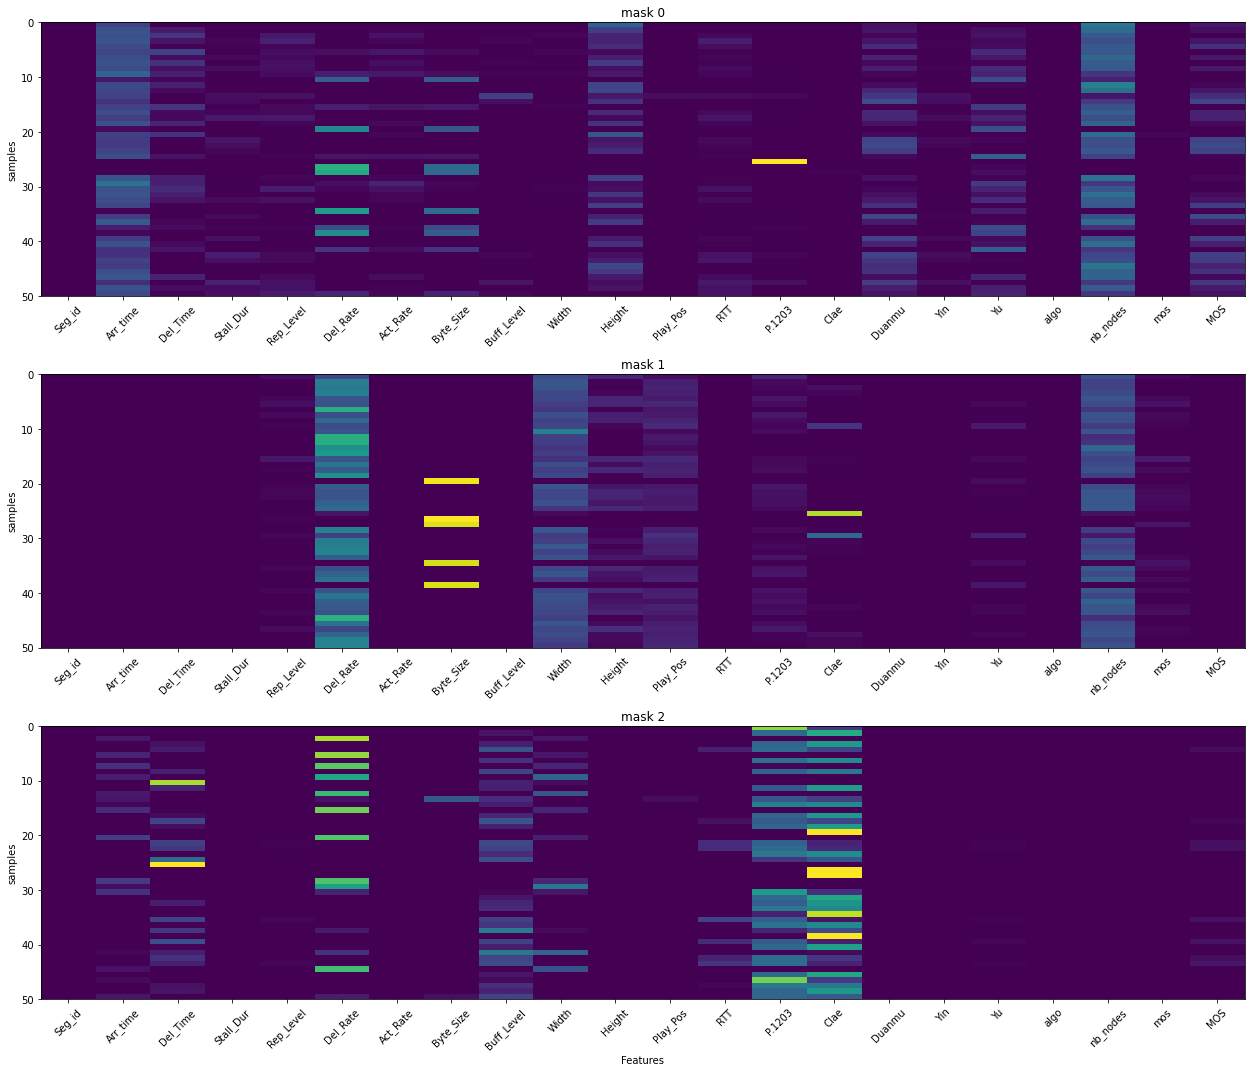

In [62]:
fig, axs = plt.subplots(3, 1, figsize=(20,15))
features_index = [x*20+10 for x in range(len(features))]
for i in range(3):
    axs[i].set_xticks(features_index)
    axs[i].imshow(masks[i][:50], extent=[0, 440, 50, 0], aspect=2)
    # axs[i].set(xticks=np.linspace(0, 23), xticklabels=np.linspace(0, 23), yticks=[0, 50], yticklabels=[0, 1]);    
    axs[i].set_xticklabels(features, rotation=45)
    axs[i].set_title(f"mask {i}")
    axs[i].set_ylabel("samples")    
axs[i].set_xlabel("Features")    
fig.tight_layout()

_**c. Discussion**_

As we saw in the results, using either accuracy or logloss does not has a considerable impact on the performance of our TabNet model.

Nevertheless, considering the little enhancement given by "accuracy", we pick it as a representative of TabNet in multi-class anomaly detection approach.